# MNIST: MLP (flattened pixels) vs CNN (2D images)

This notebook trains and compares:
- **MLP baseline** on **flattened MNIST** (28×28 → 784)
- **CNN** on **2D MNIST images** (1×28×28)

We compare:
- **Test accuracy**
- **Training time** (per epoch + total)
- **Confusion matrix**

> **Tip (Colab):** `Runtime → Change runtime type → GPU` for faster training.

In [1]:
# If running in Colab, install (usually already available)
# !pip -q install torch torchvision

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

Device: cpu


## Load MNIST

We use the standard MNIST normalization commonly used in tutorials:
- mean = 0.1307
- std  = 0.3081

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Train size:", len(train_ds), "Test size:", len(test_ds))

100%|██████████| 9.91M/9.91M [00:33<00:00, 292kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 103kB/s]
100%|██████████| 1.65M/1.65M [00:09<00:00, 173kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 735kB/s]

Train size: 60000 Test size: 10000


## Visualize a few training samples

c:\MiniForge\envs\kpitb_env\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


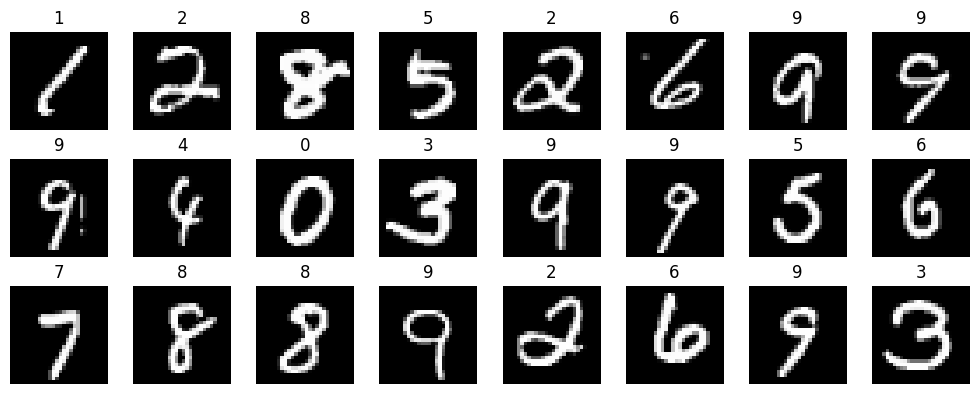

In [3]:
# Unnormalize for display
def unnormalize(x):
    return x * 0.3081 + 0.1307

imgs, labels = next(iter(train_loader))
imgs = imgs[:24]
labels = labels[:24]

plt.figure(figsize=(10, 4))
for i in range(24):
    plt.subplot(3, 8, i+1)
    plt.imshow(unnormalize(imgs[i]).squeeze(0), cmap="gray")
    plt.title(int(labels[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()

## Training utilities

In [4]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    all_preds, all_targets = [], []
    total_loss = 0.0
    total = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.cpu().numpy())

        if criterion is not None:
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            total += x.size(0)

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    acc = accuracy_score(all_targets, all_preds)
    avg_loss = (total_loss / total) if (criterion is not None and total > 0) else None
    return acc, avg_loss, all_targets, all_preds

def train_model(model, train_loader, test_loader, epochs=5, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    total_start = time.perf_counter()

    for epoch in range(1, epochs+1):
        model.train()
        epoch_start = time.perf_counter()
        running_loss = 0.0
        correct = 0
        total = 0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += x.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        test_acc, test_loss, _, _ = evaluate(model, test_loader, criterion=criterion)
        epoch_time = time.perf_counter() - epoch_start

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "epoch_time_sec": epoch_time
        })

        print(f"Epoch {epoch:02d} | "
              f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"test acc {test_acc:.4f} | "
              f"time {epoch_time:.2f}s")

    total_time = time.perf_counter() - total_start
    return model, pd.DataFrame(history), total_time

## Model 1: MLP baseline (flattened 784)

We keep the same DataLoader that yields images of shape `(N, 1, 28, 28)`.
The **MLP** will flatten internally: `x → (N, 784)`.

In [5]:
class MLP(nn.Module):
    def __init__(self, hidden1=256, hidden2=128, dropout=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 10)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = self.drop(F.relu(self.fc1(x)))
        x = self.drop(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

mlp = MLP()
print("MLP params:", count_params(mlp))

MLP params: 235146


In [6]:
epochs = 5  # for a quick demo, try 3; for better results, try 5-10

mlp_model, mlp_hist, mlp_total_time = train_model(
    model=mlp,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3
)

mlp_test_acc, _, mlp_y_true, mlp_y_pred = evaluate(mlp_model, test_loader)
print("MLP test accuracy:", mlp_test_acc)
print("MLP total train time (s):", mlp_total_time)

Epoch 01 | train loss 0.3176 acc 0.9034 | test acc 0.9623 | time 22.57s


c:\MiniForge\envs\kpitb_env\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02 | train loss 0.1334 acc 0.9584 | test acc 0.9702 | time 23.22s


c:\MiniForge\envs\kpitb_env\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 03 | train loss 0.0970 acc 0.9699 | test acc 0.9762 | time 22.58s


...

Epoch 04 | train loss 0.0814 acc 0.9750 | test acc 0.9770 | time 22.73s


c:\MiniForge\envs\kpitb_env\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 05 | train loss 0.0678 acc 0.9778 | test acc 0.9791 | time 22.25s


c:\MiniForge\envs\kpitb_env\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


MLP test accuracy: 0.9791
MLP total train time (s): 113.35797680000542


## Model 2: CNN (2D convolution on MNIST)

A small CNN with 2 convolution blocks + pooling.

In [7]:
class ComplexCNN(nn.Module):
    """A more complex CNN for MNIST."""
    def __init__(self, dropout=0.2): # Increased dropout
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1), # Input 1 channel, Output 32 channels
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output size (batch_size, 32, 14, 14)

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # Input 32 channels, Output 64 channels
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output size (batch_size, 64, 7, 7)

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # Input 64 channels, Output 128 channels
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output size (batch_size, 128, 3, 3) (7 -> floor((7-2)/2+1)=3)
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))  # (batch_size, 128, 3, 3) -> (batch_size, 128, 1, 1)
        self.drop = nn.Dropout(dropout)
        self.classifier = nn.Linear(128, 10)  # Input features from GAP is 128

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1) # Flattens (batch_size, 128, 1, 1) to (batch_size, 128)
        x = self.drop(x)
        x = self.classifier(x)
        return x

cnn = ComplexCNN() # Instantiate the new model
print("CNN params:", count_params(cnn))

CNN params: 93962


In [8]:
cnn_model, cnn_hist, cnn_total_time = train_model(
    model=cnn,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3
)

cnn_test_acc, _, cnn_y_true, cnn_y_pred = evaluate(cnn_model, test_loader)
print("CNN test accuracy:", cnn_test_acc)
print("CNN total train time (s):", cnn_total_time)

c:\MiniForge\envs\kpitb_env\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01 | train loss 0.4894 acc 0.8446 | test acc 0.9595 | time 44.54s


c:\MiniForge\envs\kpitb_env\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02 | train loss 0.1286 acc 0.9623 | test acc 0.9755 | time 46.61s


c:\MiniForge\envs\kpitb_env\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch 04 | train loss 0.0696 acc 0.9790 | test acc 0.9848 | time 46.25s


c:\MiniForge\envs\kpitb_env\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 05 | train loss 0.0595 acc 0.9818 | test acc 0.9863 | time 46.19s


c:\MiniForge\envs\kpitb_env\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


CNN test accuracy: 0.9863
CNN total train time (s): 230.1142053999938


## Compare results (accuracy + training time)

In [9]:
summary = pd.DataFrame([
    {"model": "MLP (flatten)", "params": count_params(mlp_model), "test_acc": mlp_test_acc, "train_time_sec": mlp_total_time},
    {"model": "CNN (2D)", "params": count_params(cnn_model), "test_acc": cnn_test_acc, "train_time_sec": cnn_total_time},
])

summary

,model,params,test_acc,train_time_sec
0,MLP (flatten),235146,0.9791,113.357977
1,CNN (2D),93962,0.9863,230.114205


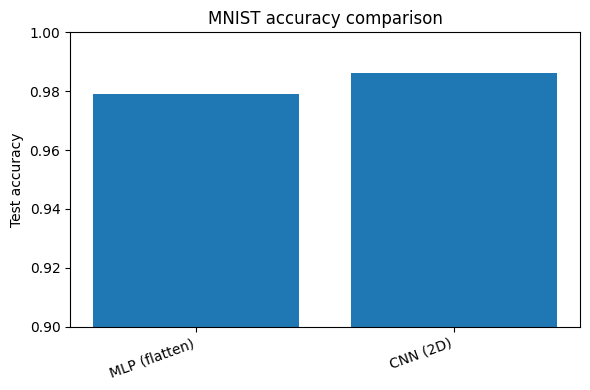

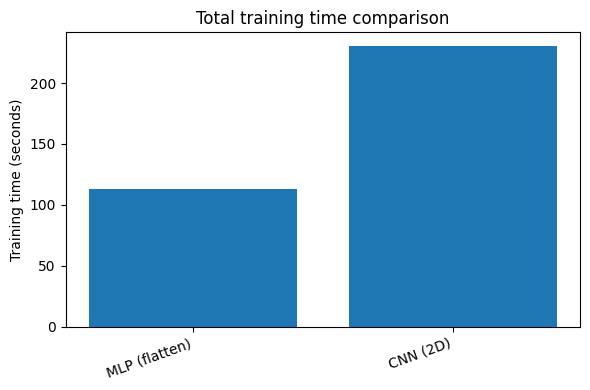

In [10]:
plt.figure(figsize=(6,4))
plt.bar(summary["model"], summary["test_acc"])
plt.ylim(0.9, 1.0)
plt.ylabel("Test accuracy")
plt.title("MNIST accuracy comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(summary["model"], summary["train_time_sec"])
plt.ylabel("Training time (seconds)")
plt.title("Total training time comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Confusion matrix (for both models)

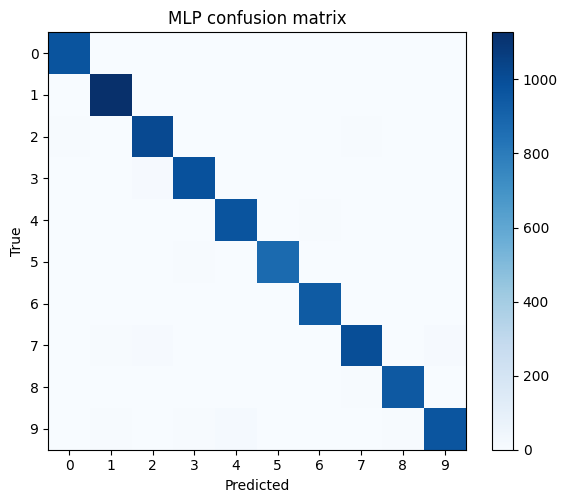

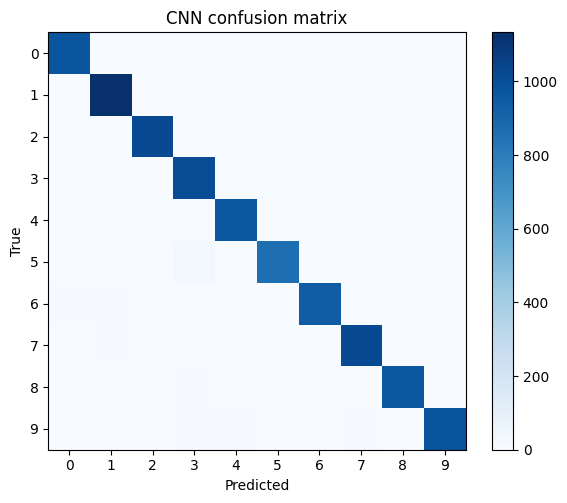

CNN classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.96      1.00      0.98      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.97      0.98       892
           6       0.99      0.98      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [11]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(10)
    plt.xticks(tick_marks, tick_marks)
    plt.yticks(tick_marks, tick_marks)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    return cm

cm_mlp = plot_confusion(mlp_y_true, mlp_y_pred, "MLP confusion matrix")
cm_cnn = plot_confusion(cnn_y_true, cnn_y_pred, "CNN confusion matrix")

print("CNN classification report:")
print(classification_report(cnn_y_true, cnn_y_pred))

## (Optional) Save plots to use in slides

This cell saves:
- accuracy bar chart
- training time bar chart
- CNN confusion matrix

You can download them from Colab (`Files` sidebar) or using `files.download`.

In [12]:
import os

os.makedirs("outputs", exist_ok=True)

# Accuracy chart
plt.figure(figsize=(6,4))
plt.bar(summary["model"], summary["test_acc"])
plt.ylim(0.9, 1.0)
plt.ylabel("Test accuracy")
plt.title("MNIST accuracy comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("outputs/accuracy_comparison.png", dpi=200)
plt.close()

# Training time chart
plt.figure(figsize=(6,4))
plt.bar(summary["model"], summary["train_time_sec"])
plt.ylabel("Training time (seconds)")
plt.title("Total training time comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("outputs/time_comparison.png", dpi=200)
plt.close()

# CNN confusion matrix
plt.figure(figsize=(6,5))
plt.imshow(confusion_matrix(cnn_y_true, cnn_y_pred), interpolation="nearest", cmap="Blues")
plt.title("CNN confusion matrix")
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("outputs/cnn_confusion_matrix.png", dpi=200)
plt.close()

summary.to_csv("outputs/summary.csv", index=False)
print("Saved outputs to ./outputs")

Saved outputs to ./outputs
